# CIFAR-10 Transfer Learning
## Phase 2: ResNet-18 | Phase 3: EfficientNet-B0
- Loads preprocessed 32×32 data from `cifar10_v3_preprocessed.npz`
- On-the-fly resize to 224×224 using PyTorch transforms
- **Phase 2:** ResNet-18 pretrained on ImageNet → Fine-tune
- **Phase 3:** EfficientNet-B0 pretrained on ImageNet → Fine-tune
- Strategy: Freeze backbone → Train head → Unfreeze → Fine-tune all

In [11]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [12]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import time
import copy

# Run from project root so all paths are uniform
if os.path.basename(os.getcwd()) == 'Model':
    os.chdir('..')

## 1. Setup Device

In [13]:
device = torch.device('mps' if torch.backends.mps.is_available() else
                       'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


## 2. Load Data + Custom Dataset with On-the-fly Resize

In [14]:
data = np.load('Preprocessing/cifar10_v3_preprocessed.npz')

X_train = data['X_train'].astype(np.float32)
X_val   = data['X_val'].astype(np.float32)
X_test  = data['X_test'].astype(np.float32)
y_train = data['y_train'].astype(np.int64) if 'y_train' in data.files else data['y_train_int'].astype(np.int64)
y_val   = data['y_val'].astype(np.int64)   if 'y_val'   in data.files else data['y_val_int'].astype(np.int64)
y_test  = data['y_test'].astype(np.int64)  if 'y_test'  in data.files else data['y_test_int'].astype(np.int64)
label_names = list(data['label_names'])

# Reverse CIFAR standardization (pretrained models expect ImageNet normalization)
cifar_mean = data['channel_mean']; cifar_std = data['channel_std']
X_train = X_train * cifar_std + cifar_mean
X_val   = X_val   * cifar_std + cifar_mean
X_test  = X_test  * cifar_std + cifar_mean

print(f'Loaded: X_train={X_train.shape}, X_val={X_val.shape}, X_test={X_test.shape}')

Loaded: X_train=(67500, 32, 32, 3), X_val=(7500, 32, 32, 3), X_test=(10000, 32, 32, 3)


In [15]:
class CIFAR10Dataset(Dataset):
    """Resize 32x32 -> 224x224 + ImageNet normalization on-the-fly"""
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx]).permute(2, 0, 1)
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

data_transform = transforms.Compose([
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = CIFAR10Dataset(X_train, y_train, transform=data_transform)
val_dataset   = CIFAR10Dataset(X_val,   y_val,   transform=data_transform)
test_dataset  = CIFAR10Dataset(X_test,  y_test,  transform=data_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=128)
test_loader  = DataLoader(test_dataset,  batch_size=128)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 1055 | Val: 59 | Test: 79


## 3. Training & Evaluation Functions

In [16]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                epochs, save_path, device, patience=5):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    best_val_acc = 0.0
    patience_counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    print(f'  Max epochs: {epochs} | Early stopping patience: {patience}')
    start = time.time()

    for epoch in range(epochs):
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)

        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                val_loss += criterion(out, yb).item() * xb.size(0)
                val_correct += (out.argmax(1) == yb).sum().item()
                val_total += xb.size(0)
        val_loss /= val_total
        val_acc = val_correct / val_total

        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch {epoch+1:2d}/{epochs} | '
                  f'Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | '
                  f'Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}% | '
                  f'LR: {current_lr:.6f} | Best: {best_val_acc*100:.2f}% | Patience: {patience_counter}/{patience}')

        if patience_counter >= patience:
            print(f'  Early stopping at epoch {epoch+1} — no improvement for {patience} epochs')
            break

    elapsed = time.time() - start
    actual_epochs = epoch + 1
    print(f'Completed in {elapsed:.1f}s | {actual_epochs}/{epochs} epochs | Best Val Acc: {best_val_acc*100:.2f}%')

    model.load_state_dict(best_model_weights)
    return model, history, best_val_acc

In [17]:
def evaluate_model(model, test_loader, label_names, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            all_preds.append(model(xb).argmax(1).cpu().numpy())
            all_labels.append(yb.numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    test_acc = (y_pred == y_true).mean()

    print(f'Test Accuracy: {test_acc*100:.2f}%')
    print(f'\nPer-Class Accuracy:')
    print('-' * 30)
    for i, name in enumerate(label_names):
        mask = y_true == i
        if mask.sum() > 0:
            acc = (y_pred[mask] == i).mean()
            print(f'  {name:<12s}: {acc*100:.1f}%')

    print(f'\n{classification_report(y_true, y_pred, target_names=label_names)}')
    return y_pred, y_true, test_acc

In [18]:
def plot_results(history, y_pred, y_true, test_acc, label_names, model_name, save_prefix):
    epochs_range = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', alpha=0.8)
    ax1.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', alpha=0.8)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss Over Epochs')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_range, history['train_acc'], 'b-', label='Train Acc', alpha=0.8)
    ax2.plot(epochs_range, history['val_acc'], 'r-', label='Val Acc', alpha=0.8)
    ax2.axhline(y=test_acc, color='green', linestyle='--', label=f'Test: {test_acc*100:.2f}%')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy Over Epochs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f'{model_name} \u2014 Test: {test_acc*100:.2f}%', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_curves.png', dpi=150)
    plt.show()

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(label_names, rotation=45, ha='right')
    ax.set_yticklabels(label_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{model_name} \u2014 Test Accuracy: {test_acc*100:.2f}%')
    for i in range(10):
        for j in range(10):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=9)
    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_confusion.png', dpi=150)
    plt.show()

---
# Phase 2: ResNet-18 (Transfer Learning)

**Strategy:**
1. Load ResNet-18 pretrained on ImageNet (1.2M images, 1000 classes)
2. **Freeze** all backbone layers (keep ImageNet knowledge)
3. Replace last FC layer: 1000 classes \u2192 10 classes
4. Train only the new head for 10 epochs (fast)
5. **Unfreeze** entire model
6. Fine-tune all layers with small LR for 20 epochs

## Phase 2.1: Load Pretrained ResNet-18 + Freeze Backbone

In [19]:
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in resnet.parameters():
    param.requires_grad = False

num_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, 10)
)

resnet = resnet.to(device)

total_params = sum(p.numel() for p in resnet.parameters())
trainable_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params
print(f'Total params:     {total_params:,}')
print(f'Frozen params:    {frozen_params:,}')
print(f'Trainable params: {trainable_params:,} (only the new head)')

Total params:     11,181,642
Frozen params:    11,176,512
Trainable params: 5,130 (only the new head)


## Phase 2.2: Train Head Only (Frozen Backbone) \u2014 10 Epochs

In [20]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_head = optim.Adam(resnet.fc.parameters(), lr=0.001)
scheduler_head = optim.lr_scheduler.CosineAnnealingLR(optimizer_head, T_max=10)

print('=== Phase 2.2: Training HEAD only (backbone frozen) ===')
resnet, history_head, best_head_acc = train_model(
    resnet, train_loader, val_loader, criterion,
    optimizer_head, scheduler_head,
    epochs=10, save_path='Model/best_resnet18_head.pth', device=device
)

=== Phase 2.2: Training HEAD only (backbone frozen) ===
  Max epochs: 10 | Early stopping patience: 5
Epoch  1/10 | Train Loss: 1.4841 Acc: 56.95% | Val Loss: 1.2643 Acc: 67.47% | LR: 0.001000 | Best: 67.47% | Patience: 0/5
Epoch  5/10 | Train Loss: 1.3738 Acc: 62.38% | Val Loss: 1.2424 Acc: 68.76% | LR: 0.000655 | Best: 68.76% | Patience: 0/5
Epoch 10/10 | Train Loss: 1.3443 Acc: 63.78% | Val Loss: 1.2367 Acc: 69.01% | LR: 0.000024 | Best: 69.01% | Patience: 0/5
Completed in 2113.9s | 10/10 epochs | Best Val Acc: 69.01%


## Phase 2.3: Unfreeze + Fine-tune All Layers \u2014 20 Epochs

In [21]:
for param in resnet.parameters():
    param.requires_grad = True

optimizer_ft = optim.SGD(resnet.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=20)

print('=== Phase 2.3: Fine-tuning ALL layers ===')
resnet, history_ft, best_ft_acc = train_model(
    resnet, train_loader, val_loader, criterion,
    optimizer_ft, scheduler_ft,
    epochs=20, save_path='Model/best_resnet18_finetuned.pth', device=device
)

=== Phase 2.3: Fine-tuning ALL layers ===
  Max epochs: 20 | Early stopping patience: 5
Epoch  1/20 | Train Loss: 0.9805 Acc: 81.76% | Val Loss: 0.8190 Acc: 88.75% | LR: 0.001000 | Best: 88.75% | Patience: 0/5
Epoch  5/20 | Train Loss: 0.6593 Acc: 96.65% | Val Loss: 0.7287 Acc: 91.95% | LR: 0.000905 | Best: 91.95% | Patience: 0/5
Epoch 10/20 | Train Loss: 0.5844 Acc: 99.59% | Val Loss: 0.7176 Acc: 92.36% | LR: 0.000578 | Best: 92.39% | Patience: 1/5
Epoch 15/20 | Train Loss: 0.5645 Acc: 99.90% | Val Loss: 0.7129 Acc: 92.48% | LR: 0.000206 | Best: 92.59% | Patience: 2/5
  Early stopping at epoch 18 — no improvement for 5 epochs
Completed in 12181.7s | 18/20 epochs | Best Val Acc: 92.59%


## Phase 2.4: ResNet-18 Test Evaluation

In [22]:
resnet.load_state_dict(torch.load('Model/best_resnet18_finetuned.pth', weights_only=True))
print('=== ResNet-18 Test Results ===')
resnet_pred, resnet_true, resnet_test_acc = evaluate_model(resnet, test_loader, label_names, device)

=== ResNet-18 Test Results ===
Test Accuracy: 92.87%

Per-Class Accuracy:
------------------------------
  airplane    : 94.6%
  automobile  : 97.5%
  bird        : 90.1%
  cat         : 84.4%
  deer        : 92.9%
  dog         : 89.0%
  frog        : 95.0%
  horse       : 94.0%
  ship        : 97.2%
  truck       : 94.0%

              precision    recall  f1-score   support

    airplane       0.95      0.95      0.95      1000
  automobile       0.95      0.97      0.96      1000
        bird       0.93      0.90      0.91      1000
         cat       0.86      0.84      0.85      1000
        deer       0.91      0.93      0.92      1000
         dog       0.88      0.89      0.88      1000
        frog       0.93      0.95      0.94      1000
       horse       0.96      0.94      0.95      1000
        ship       0.95      0.97      0.96      1000
       truck       0.97      0.94      0.95      1000

    accuracy                           0.93     10000
   macro avg       0.93 

In [23]:
def plot_results(history, y_pred, y_true, test_acc, label_names, model_name, save_prefix):
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss'); ax1.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(epochs_range, history['train_acc'], 'b-', label='Train Acc'); ax2.plot(epochs_range, history['val_acc'], 'r-', label='Val Acc')
    ax2.axhline(y=test_acc, color='green', linestyle='--', label=f'Test: {test_acc*100:.2f}%')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.suptitle(f'{model_name} — Test: {test_acc*100:.2f}%', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'Figure/{save_prefix}_curves.png', dpi=150)
    plt.show()

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(label_names, rotation=45, ha='right'); ax.set_yticklabels(label_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{model_name} — Test: {test_acc*100:.2f}%')
    for i in range(10):
        for j in range(10):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=9)
    plt.colorbar(im); plt.tight_layout()
    plt.savefig(f'Figure/{save_prefix}_confusion.png', dpi=150)
    plt.show()

---
# Phase 3: EfficientNet-B0 (Transfer Learning)

**Why EfficientNet?**
- More efficient than ResNet (fewer params, better accuracy)
- Uses compound scaling (depth + width + resolution)
- EfficientNet-B0 is the smallest variant \u2014 fast to train

**Same strategy:**
1. Freeze backbone \u2192 Train head (10 epochs)
2. Unfreeze \u2192 Fine-tune all (20 epochs)

## Phase 3.1: Load Pretrained EfficientNet-B0 + Freeze Backbone

In [24]:
effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

for param in effnet.parameters():
    param.requires_grad = False

num_features_eff = effnet.classifier[1].in_features
effnet.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features_eff, 10)
)

effnet = effnet.to(device)

total_params_eff = sum(p.numel() for p in effnet.parameters())
trainable_params_eff = sum(p.numel() for p in effnet.parameters() if p.requires_grad)
frozen_params_eff = total_params_eff - trainable_params_eff
print(f'Total params:     {total_params_eff:,}')
print(f'Frozen params:    {frozen_params_eff:,}')
print(f'Trainable params: {trainable_params_eff:,} (only the new head)')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/mjabed3834/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100.0%


Total params:     4,020,358
Frozen params:    4,007,548
Trainable params: 12,810 (only the new head)


## Phase 3.2: Train Head Only (Frozen Backbone) \u2014 10 Epochs

In [25]:
criterion_eff = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_eff_head = optim.Adam(effnet.classifier.parameters(), lr=0.001)
scheduler_eff_head = optim.lr_scheduler.CosineAnnealingLR(optimizer_eff_head, T_max=10)

print('=== Phase 3.2: Training HEAD only (backbone frozen) ===')
effnet, eff_history_head, eff_best_head = train_model(
    effnet, train_loader, val_loader, criterion_eff,
    optimizer_eff_head, scheduler_eff_head,
    epochs=10, save_path='Model/best_effnet_head.pth', device=device
)

=== Phase 3.2: Training HEAD only (backbone frozen) ===
  Max epochs: 10 | Early stopping patience: 5
Epoch  1/10 | Train Loss: 1.4415 Acc: 59.97% | Val Loss: 1.2480 Acc: 68.69% | LR: 0.001000 | Best: 68.69% | Patience: 0/5
Epoch  5/10 | Train Loss: 1.3193 Acc: 65.22% | Val Loss: 1.2149 Acc: 69.85% | LR: 0.000655 | Best: 70.31% | Patience: 2/5
Epoch 10/10 | Train Loss: 1.2964 Acc: 66.19% | Val Loss: 1.2036 Acc: 70.76% | LR: 0.000024 | Best: 70.76% | Patience: 0/5
Completed in 3153.6s | 10/10 epochs | Best Val Acc: 70.76%


## Phase 3.3: Unfreeze + Fine-tune All Layers \u2014 20 Epochs

In [26]:
for param in effnet.parameters():
    param.requires_grad = True

optimizer_eff_ft = optim.SGD(effnet.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler_eff_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_eff_ft, T_max=20)

print('=== Phase 3.3: Fine-tuning ALL layers ===')
effnet, eff_history_ft, eff_best_ft = train_model(
    effnet, train_loader, val_loader, criterion_eff,
    optimizer_eff_ft, scheduler_eff_ft,
    epochs=20, save_path='Model/best_effnet_finetuned.pth', device=device
)

=== Phase 3.3: Fine-tuning ALL layers ===
  Max epochs: 20 | Early stopping patience: 5
Epoch  1/20 | Train Loss: 1.0119 Acc: 79.79% | Val Loss: 0.8396 Acc: 87.65% | LR: 0.001000 | Best: 87.65% | Patience: 0/5
Epoch  5/20 | Train Loss: 0.7066 Acc: 93.02% | Val Loss: 0.6872 Acc: 93.13% | LR: 0.000905 | Best: 93.13% | Patience: 0/5
Epoch 10/20 | Train Loss: 0.6399 Acc: 95.84% | Val Loss: 0.6514 Acc: 94.43% | LR: 0.000578 | Best: 94.49% | Patience: 1/5
Epoch 15/20 | Train Loss: 0.6186 Acc: 96.67% | Val Loss: 0.6406 Acc: 94.95% | LR: 0.000206 | Best: 94.95% | Patience: 0/5
Epoch 20/20 | Train Loss: 0.6155 Acc: 96.81% | Val Loss: 0.6402 Acc: 94.91% | LR: 0.000006 | Best: 95.07% | Patience: 3/5
Completed in 20469.0s | 20/20 epochs | Best Val Acc: 95.07%


## Phase 3.4: EfficientNet-B0 Test Evaluation

In [27]:
effnet.load_state_dict(torch.load('Model/best_effnet_finetuned.pth', weights_only=True))
print('=== EfficientNet-B0 Test Results ===')
eff_pred, eff_true, eff_test_acc = evaluate_model(effnet, test_loader, label_names, device)

=== EfficientNet-B0 Test Results ===
Test Accuracy: 95.16%

Per-Class Accuracy:
------------------------------
  airplane    : 96.2%
  automobile  : 96.8%
  bird        : 94.3%
  cat         : 87.8%
  deer        : 95.5%
  dog         : 93.4%
  frog        : 97.6%
  horse       : 96.3%
  ship        : 97.5%
  truck       : 96.2%

              precision    recall  f1-score   support

    airplane       0.96      0.96      0.96      1000
  automobile       0.96      0.97      0.97      1000
        bird       0.96      0.94      0.95      1000
         cat       0.92      0.88      0.90      1000
        deer       0.94      0.95      0.95      1000
         dog       0.90      0.93      0.92      1000
        frog       0.96      0.98      0.97      1000
       horse       0.97      0.96      0.97      1000
        ship       0.97      0.97      0.97      1000
       truck       0.96      0.96      0.96      1000

    accuracy                           0.95     10000
   macro avg      

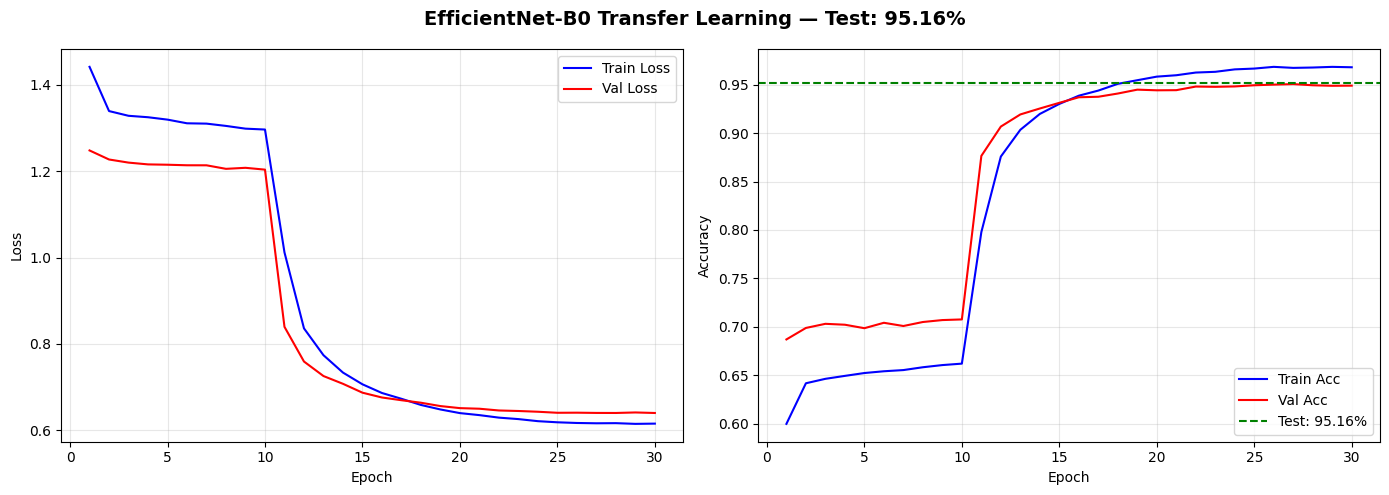

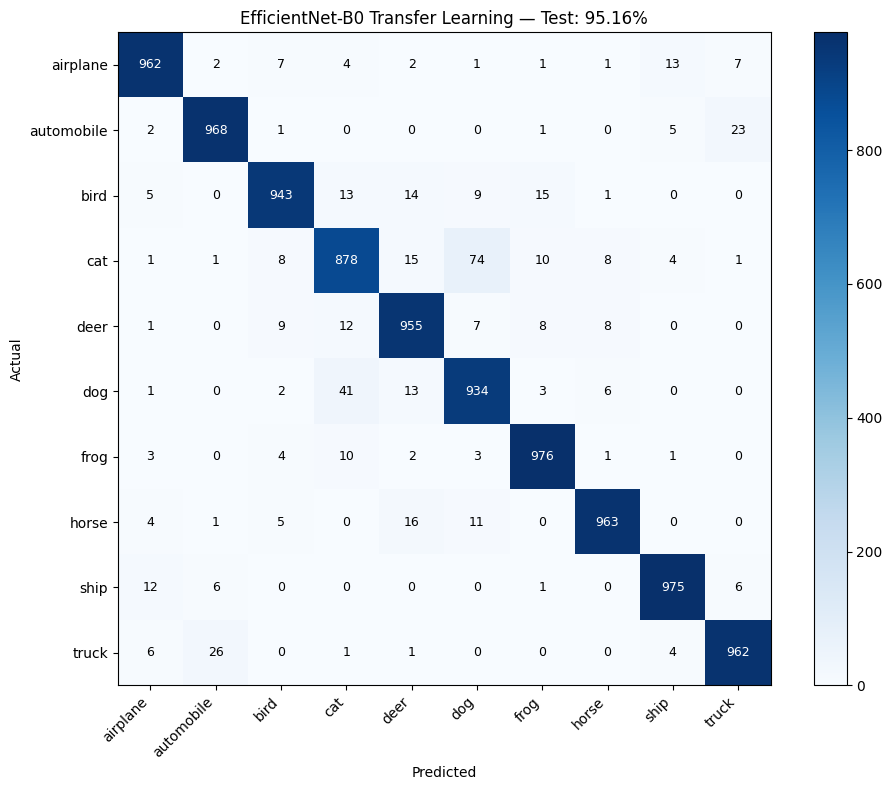

In [28]:
eff_history = {}
for key in ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'lr']:
    eff_history[key] = eff_history_head[key] + eff_history_ft[key]

plot_results(eff_history, eff_pred, eff_true, eff_test_acc,
             label_names, 'EfficientNet-B0 Transfer Learning', 'efficientnet')

---
# Final Comparison: All Models

In [29]:
print('=' * 60)
print('FINAL COMPARISON')
print('=' * 60)
print(f'{"Model":<25s} {"Test Acc":>10s} {"Params":>12s}')
print('-' * 50)
print(f'{"Custom CNN (32x32)":<25s} {"88.94%":>10s} {"3.25M":>12s}')
print(f'{"ResNet-18 (pretrained)":<25s} {resnet_test_acc*100:>9.2f}% {"11.2M":>12s}')
print(f'{"EfficientNet-B0 (pre)":<25s} {eff_test_acc*100:>9.2f}% {"5.3M":>12s}')
print('=' * 60)

FINAL COMPARISON
Model                       Test Acc       Params
--------------------------------------------------
Custom CNN (32x32)            88.94%        3.25M
ResNet-18 (pretrained)        92.87%        11.2M
EfficientNet-B0 (pre)         95.16%         5.3M


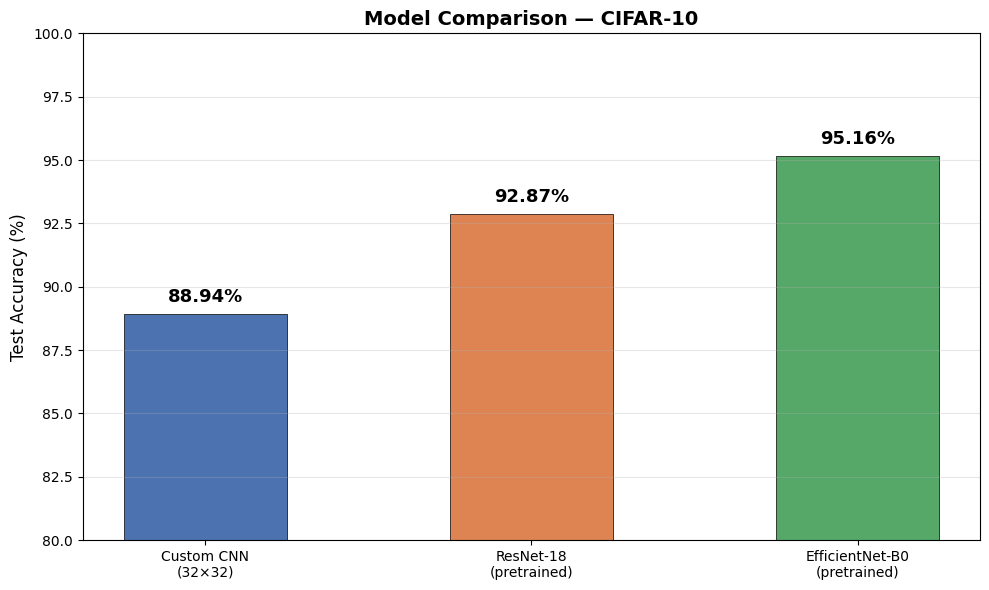

In [30]:
models_names = ['Custom CNN\n(32×32)', 'ResNet-18\n(pretrained)', 'EfficientNet-B0\n(pretrained)']
accuracies = [88.94, resnet_test_acc * 100, eff_test_acc * 100]
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models_names, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — CIFAR-10', fontsize=14, fontweight='bold')
ax.set_ylim(80, 100); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Figure/model_comparison.png', dpi=150)
plt.show()

## Summary

| Phase | Model | Strategy | Epochs | Expected Acc |
|---|---|---|---|---|
| 1 (done) | Custom CNN | Train from scratch | 50 | ~89% |
| **2** | **ResNet-18** | Freeze \u2192 Train head \u2192 Unfreeze \u2192 Fine-tune | 10 + 20 | ~94-95% |
| **3** | **EfficientNet-B0** | Freeze \u2192 Train head \u2192 Unfreeze \u2192 Fine-tune | 10 + 20 | ~95-97% |

### Key Techniques Used
| Technique | Purpose |
|---|---|
| Transfer Learning | Reuse ImageNet features instead of learning from scratch |
| Freeze + Unfreeze | Prevent destroying pretrained weights early on |
| ImageNet Normalization | Match the stats pretrained models were trained with |
| Label Smoothing (0.1) | Reduce overconfidence, improve generalization |
| SGD + Momentum | Better generalization than Adam for fine-tuning |
| CosineAnnealingLR | Smooth LR decay for stable fine-tuning |
| On-the-fly Resize | Save memory (no need to store 224\u00d7224 images) |